# Fine-tuning FinBERT on the Financial PhraseBank

Notebook 3 of 7, the only one that runs on a GPU. It fine-tunes a FinBERT that has never seen the PhraseBank, chooses every setting on the validation split, and writes the headline model with its validation and test probabilities. Test metrics are not computed here; notebook 4 computes them once.

Two starting checkpoints compete inside the search: `yiyanghkust/finbert-pretrain`, pretrained on 4.9 billion tokens of 10-K and 10-Q filings, earnings call transcripts and analyst reports, and `yiyanghkust/finbert-tone`, the same model already fine-tuned on 10,000 analyst-report sentences. The popular `ProsusAI/finbert` is scored at the end only as a reference: its model card states it was fine-tuned on the Financial PhraseBank, so it has probably seen this test split.

## Setup and determinism

The environment variables must be set before PyTorch initialises CUDA: `CUBLAS_WORKSPACE_CONFIG` lets cuBLAS run deterministically and `CUDA_VISIBLE_DEVICES` keeps one of the two T4s. PyTorch is then put in deterministic mode with TF32 off and attention in its eager implementation, so two runs on the same GPU type produce identical numbers. `SMOKE` trains on 400 sentences for one epoch with two trials, and prints the GPU model and a hash of the validation logits so two smoke runs can be compared before any long run.

In [1]:
import os

os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

import gc
import hashlib
import importlib.util
import json
import math
import random
import shutil
import subprocess
import sys
import time
from pathlib import Path

if importlib.util.find_spec("transformers") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "--progress-bar", "off", "transformers"], check=True, capture_output=True)

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import tokenizers
import torch
import transformers
from cycler import cycler
from huggingface_hub import snapshot_download
from tokenizers import BertWordPieceTokenizer
from transformers import BertForSequenceClassification

SMOKE = False
SEED = 42
TRIALS = 2 if SMOKE else 20
FINAL_SEEDS = [42, 43, 44]
MAX_LENGTH = 128
EVAL_BATCH = 128
LABELS = ["negative", "neutral", "positive"]
CHECKPOINTS = {
    "finbert-pretrain": ("yiyanghkust/finbert-pretrain", "88ab954a39ea6d3ce2b62cff086dd5ad1172c664"),
    "finbert-tone": ("yiyanghkust/finbert-tone", "4921590d3c0c3832c0efea24c8381ce0bda7844b"),
}
PROSUS = ("ProsusAI/finbert", "4556d13015211d73dccd3fdd39d39232506f3e43")
INPUT = Path("/kaggle/input")
OUT = Path("/kaggle/working")
HUB = Path("/tmp/hub")
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "text.color": INK, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2, "legend.frameon": False,
    "font.family": "sans-serif", "axes.prop_cycle": cycler(color=SERIES), "axes.titlesize": 11,
})
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
transformers.logging.set_verbosity_error()
optuna.logging.set_verbosity(optuna.logging.WARNING)
if not torch.cuda.is_available():
    devices = subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True).stdout.strip() if shutil.which("nvidia-smi") else "nvidia-smi not found"
    raise RuntimeError(f"this notebook needs a GPU session (torch {torch.__version__}, CUDA build {torch.version.cuda}, devices: {devices or 'none'})")
DEVICE = torch.device("cuda")
START = time.time()


def find_file(name):
    hits = sorted(INPUT.rglob(name))
    if not hits:
        raise FileNotFoundError(name)
    return hits[0]


def save(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=110, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def elapsed():
    return f"elapsed {(time.time() - START) / 60:.1f} minutes"


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def free():
    gc.collect()
    torch.cuda.empty_cache()


def fetch(repo, revision):
    target = HUB / repo.replace("/", "__")
    snapshot_download(repo_id=repo, revision=revision, local_dir=str(target), allow_patterns=["config.json", "pytorch_model.bin", "vocab.txt"])
    return target


def make_tokenizer(vocab):
    tokenizer = BertWordPieceTokenizer(str(vocab), lowercase=True)
    tokenizer.enable_truncation(MAX_LENGTH)
    return tokenizer


def encode(tokenizer, texts):
    return [encoding.ids for encoding in tokenizer.encode_batch(list(texts))]


def collate(seqs):
    width = max(len(s) for s in seqs)
    ids = np.zeros((len(seqs), width), dtype=np.int64)
    mask = np.zeros_like(ids)
    for i, s in enumerate(seqs):
        ids[i, :len(s)] = s
        mask[i, :len(s)] = 1
    return torch.from_numpy(ids).to(DEVICE), torch.from_numpy(mask).to(DEVICE)


def softmax(logits):
    z = logits.astype(np.float64) - logits.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


def accuracy(scores, labels):
    return float(np.mean(np.asarray(scores).argmax(axis=1) == labels))


@torch.no_grad()
def predict_logits(model, seqs):
    model.eval()
    out = []
    for start in range(0, len(seqs), EVAL_BATCH):
        ids, mask = collate(seqs[start:start + EVAL_BATCH])
        out.append(model(input_ids=ids, attention_mask=mask, token_type_ids=torch.zeros_like(ids)).logits.float().cpu().numpy())
    return np.concatenate(out)


print(f"smoke={SMOKE}")
print(f"torch {torch.__version__}, transformers {transformers.__version__}, tokenizers {tokenizers.__version__}, optuna {optuna.__version__}, numpy {np.__version__}")
if SMOKE:
    print(f"gpu {torch.cuda.get_device_name(0)}, cuda {torch.version.cuda}")

smoke=False
torch 2.11.0+cu128, transformers 5.16.1, tokenizers 0.23.1, optuna 5.0.0, numpy 2.1.3


**Conclusion.** The smoke switch is off. The GPU image provides PyTorch 2.11.0 built for CUDA 12.8, transformers 5.16.1, tokenizers 0.23.1, Optuna 5.0.0 and NumPy 2.1.3, so the conditional install did not run. The GPU model is printed only in smoke runs: both smoke runs reported a Tesla T4 and an identical hash of the validation logits, which is what cleared this long run.

## The splits from notebook 2

Reads the clean table and keeps its split column as is. The smoke run trains on 400 training sentences and validates on 200, enough to exercise every code path.

In [2]:
table = pd.read_parquet(find_file("phrasebank.parquet"))
splits = {name: table[table["split"] == name].sort_values("sentence_id") for name in ("train", "val", "test")}
if SMOKE:
    splits["train"] = splits["train"].sample(400, random_state=SEED).sort_values("sentence_id")
    splits["val"] = splits["val"].iloc[:200]
labels = {name: rows["label"].to_numpy() for name, rows in splits.items()}
for name, rows in splits.items():
    print(f"{name}: {len(rows):,} sentences; " + ", ".join(f"{LABELS[k]} {v}" for k, v in rows["label"].value_counts().sort_index().items()))

train: 3,868 sentences; negative 484, neutral 2296, positive 1088
val: 484 sentences; negative 60, neutral 287, positive 137
test: 484 sentences; negative 60, neutral 288, positive 136


**Conclusion.** The full splits are in use: 3,868 training sentences (484 negative, 2,296 neutral, 1,088 positive), 484 validation and 484 test, the counts notebook 2 wrote.

## Checkpoints, vocabulary and token lengths

Downloads both candidate checkpoints at their pinned revisions. FinBERT uses its own vocabulary (FinVocab); the cell confirms it is uncased (no entry outside the special tokens contains an uppercase letter), which is why the tokeniser lowercases. It then measures sentence lengths in tokens to see how many sentences the 128-token limit truncates, and loads each checkpoint once to list which tensors start untrained: the classification head for `finbert-pretrain`, nothing for `finbert-tone`, whose 3-way head is reused with its rows reordered from (Neutral, Positive, Negative) to this project's order.

In [3]:
paths = {name: fetch(repo, revision) for name, (repo, revision) in CHECKPOINTS.items()}
vocabs = {name: (path / "vocab.txt").read_text(encoding="utf-8").splitlines() for name, path in paths.items()}
for name, vocab in vocabs.items():
    upper = sum(any(c.isupper() for c in token) for token in vocab if not token.startswith("["))
    print(f"{name}: {len(vocab):,} vocabulary entries, {upper} with an uppercase letter outside special tokens")
print(f"identical vocabularies: {vocabs['finbert-pretrain'] == vocabs['finbert-tone']}")
tokenizers_by_name = {name: make_tokenizer(path / "vocab.txt") for name, path in paths.items()}
untruncated = BertWordPieceTokenizer(str(paths["finbert-pretrain"] / "vocab.txt"), lowercase=True)
lengths = np.array([len(e.ids) for e in untruncated.encode_batch(table["sentence"].tolist())])
print(f"tokens per sentence including [CLS] and [SEP]: median {np.median(lengths):.0f}, 99th percentile {np.percentile(lengths, 99):.0f}, max {lengths.max()}")
print(f"sentences longer than {MAX_LENGTH} tokens, truncated: {int((lengths > MAX_LENGTH).sum())}")
ids = {name: {split: encode(tok, rows["sentence"]) for split, rows in splits.items()} for name, tok in tokenizers_by_name.items()}
for name, path in paths.items():
    extra = {"num_labels": 3} if name == "finbert-pretrain" else {}
    model, info = BertForSequenceClassification.from_pretrained(path, attn_implementation="eager", output_loading_info=True, **extra)
    print(f"{name}: {sum(p.numel() for p in model.parameters()):,} parameters; newly initialised {sorted(info['missing_keys'])}; unused checkpoint tensors {len(info['unexpected_keys'])}")
    if name == "finbert-tone":
        print(f"finbert-tone head labels: {model.config.id2label}")
    del model
print(elapsed())

finbert-pretrain: 30,873 vocabulary entries, 24 with an uppercase letter outside special tokens
finbert-tone: 30,873 vocabulary entries, 24 with an uppercase letter outside special tokens
identical vocabularies: True
tokens per sentence including [CLS] and [SEP]: median 28, 99th percentile 68, max 134
sentences longer than 128 tokens, truncated: 1
finbert-pretrain: 109,754,115 parameters; newly initialised ['classifier.bias', 'classifier.weight']; unused checkpoint tensors 8
finbert-tone: 109,754,115 parameters; newly initialised []; unused checkpoint tensors 0
finbert-tone head labels: {0: 'Neutral', 1: 'Positive', 2: 'Negative'}
elapsed 0.2 minutes


**Conclusion.** Both checkpoints share one 30,873-entry FinVocab vocabulary, and only 24 entries outside the bracketed special tokens contain an uppercase letter, so it is effectively uncased and lowercasing is right. Sentences have a median of 28 tokens, a 99th percentile of 68 and a maximum of 134, so the 128-token limit truncates a single sentence. finbert-pretrain loads every encoder weight and starts only its 3-way classifier from scratch (its 8 unused tensors are the masked-language-model head); finbert-tone loads completely, with its head labelled Neutral, Positive, Negative.

## The training loop

`build_model` seeds PyTorch before loading, so a new head starts from the same weights in every run, and reorders the `finbert-tone` head to negative, neutral, positive. `train_model` is plain PyTorch: AdamW with no weight decay on biases and LayerNorm weights, linear warmup then linear decay, gradient clipping at 1.0, and a seeded shuffle each epoch. Batches are padded only to their longest sentence. The cell defines the functions and prints the head mapping it will apply.

In [4]:
def build_model(name, seed):
    torch.manual_seed(seed)
    path = paths[name]
    if name == "finbert-pretrain":
        model = BertForSequenceClassification.from_pretrained(path, num_labels=3, attn_implementation="eager")
    else:
        model = BertForSequenceClassification.from_pretrained(path, attn_implementation="eager")
        source = [model.config.id2label[i].lower() for i in range(3)]
        rows = [source.index(label) for label in LABELS]
        with torch.no_grad():
            model.classifier.weight.copy_(model.classifier.weight[rows].clone())
            model.classifier.bias.copy_(model.classifier.bias[rows].clone())
    model.config.id2label = dict(enumerate(LABELS))
    model.config.label2id = {label: i for i, label in enumerate(LABELS)}
    return model.to(DEVICE)


def train_model(params, seed, track=False):
    set_seed(seed)
    name = params["checkpoint"]
    model = build_model(name, seed)
    seqs, target = ids[name]["train"], torch.tensor(labels["train"], dtype=torch.long)
    decay = [p for n, p in model.named_parameters() if not (n.endswith("bias") or "LayerNorm" in n)]
    no_decay = [p for n, p in model.named_parameters() if n.endswith("bias") or "LayerNorm" in n]
    optimizer = torch.optim.AdamW([{"params": decay, "weight_decay": params["weight_decay"]}, {"params": no_decay, "weight_decay": 0.0}], lr=params["lr"])
    epochs = 1 if SMOKE else params["epochs"]
    batch = params["batch_size"]
    total = math.ceil(len(seqs) / batch) * epochs
    warm = int(params["warmup"] * total)
    schedule = torch.optim.lr_scheduler.LambdaLR(optimizer, lambda step: step / max(1, warm) if step < warm else max(0.0, (total - step) / max(1, total - warm)))
    generator = torch.Generator().manual_seed(seed)
    curve = []
    for _ in range(epochs):
        model.train()
        order = torch.randperm(len(seqs), generator=generator).tolist()
        for start in range(0, len(order), batch):
            chosen = order[start:start + batch]
            input_ids, mask = collate([seqs[i] for i in chosen])
            logits = model(input_ids=input_ids, attention_mask=mask, token_type_ids=torch.zeros_like(input_ids)).logits
            loss = torch.nn.functional.cross_entropy(logits, target[chosen].to(DEVICE))
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            schedule.step()
        if track:
            curve.append(accuracy(predict_logits(model, ids[name]["val"]), labels["val"]))
    return model, curve


probe = BertForSequenceClassification.from_pretrained(paths["finbert-tone"], attn_implementation="eager")
source = [probe.config.id2label[i].lower() for i in range(3)]
print(f"finbert-tone head rows {source} are reordered by {[source.index(label) for label in LABELS]} to {LABELS}")
del probe

finbert-tone head rows ['neutral', 'positive', 'negative'] are reordered by [2, 0, 1] to ['negative', 'neutral', 'positive']


**Conclusion.** The functions are defined, and the finbert-tone head rows are reordered by [2, 0, 1], so its neutral, positive and negative rows line up with this project's negative, neutral and positive order.

## Search on the validation split

A bounded Optuna study (TPE sampler, seed 42, 20 trials) picks the checkpoint, learning rate, number of epochs, warmup share, weight decay and batch size. Each trial trains once with seed 42 and is scored by validation accuracy after its last epoch, the lead metric of the benchmark. The test split plays no part. Elapsed and projected minutes are printed after every trial.

In [5]:
search_start = time.time()


def objective(trial):
    params = {
        "checkpoint": trial.suggest_categorical("checkpoint", list(CHECKPOINTS)),
        "lr": trial.suggest_float("lr", 1e-5, 8e-5, log=True),
        "epochs": trial.suggest_categorical("epochs", [2, 3, 4, 5]),
        "warmup": trial.suggest_float("warmup", 0.0, 0.2),
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 0.1),
        "batch_size": trial.suggest_categorical("batch_size", [16, 32]),
    }
    started = time.time()
    model, _ = train_model(params, SEED)
    value = accuracy(predict_logits(model, ids[params["checkpoint"]]["val"]), labels["val"])
    del model
    free()
    spent = (time.time() - search_start) / 60
    shown = ", ".join(f"{k} {v:.3g}" if isinstance(v, float) else f"{k} {v}" for k, v in params.items())
    print(f"trial {trial.number}: validation accuracy {value:.4f}; {shown}")
    print(f"trial {trial.number} took {(time.time() - started) / 60:.1f} minutes, elapsed {spent:.1f} minutes, projected {spent / (trial.number + 1) * TRIALS:.1f} minutes")
    return value


study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=TRIALS)
best = dict(study.best_params)
print(f"best trial {study.best_trial.number}: validation accuracy {study.best_value:.4f}")
print(f"best settings: {best}")
by_checkpoint = pd.DataFrame([{"checkpoint": t.params["checkpoint"], "value": t.value} for t in study.trials]).groupby("checkpoint")["value"].agg(["count", "mean", "max"])
print(by_checkpoint.round(4).to_string())

trial 0: validation accuracy 0.8698; checkpoint finbert-tone, lr 4.58e-05, epochs 2, warmup 0.173, weight_decay 0.0601, batch_size 16
trial 0 took 1.5 minutes, elapsed 1.5 minutes, projected 30.1 minutes
trial 1: validation accuracy 0.8574; checkpoint finbert-pretrain, lr 1.56e-05, epochs 5, warmup 0.0864, weight_decay 0.0291, batch_size 16
trial 1 took 3.9 minutes, elapsed 5.4 minutes, projected 54.2 minutes
trial 2: validation accuracy 0.8574; checkpoint finbert-tone, lr 2.58e-05, epochs 2, warmup 0.00929, weight_decay 0.0608, batch_size 16
trial 2 took 1.6 minutes, elapsed 7.0 minutes, projected 46.8 minutes
trial 3: validation accuracy 0.8595; checkpoint finbert-tone, lr 5.37e-05, epochs 4, warmup 0.0244, weight_decay 0.0495, batch_size 32
trial 3 took 3.0 minutes, elapsed 10.0 minutes, projected 50.0 minutes
trial 4: validation accuracy 0.8595; checkpoint finbert-tone, lr 1.91e-05, epochs 5, warmup 0.155, weight_decay 0.0939, batch_size 16
trial 4 took 3.9 minutes, elapsed 13.9 mi

**Conclusion.** The 20 trials took 59.9 minutes on the T4, and validation accuracy stayed in a narrow band from 85.54% to 87.81%. The best, trial 17, starts from finbert-pretrain with learning rate 1.56e-5, 4 epochs, 14.5% warmup, weight decay 0.009 and batch size 32. TPE drew finbert-pretrain 12 times and it has the higher mean (86.74% against 86.42% for finbert-tone), but the gap is small: the analyst-report tone fine-tuning gives no visible head start on the PhraseBank.

## Three seeds of the best configuration

Fine-tuning results move with the random seed, so the best configuration is retrained with seeds 42, 43 and 44, tracking validation accuracy after every epoch. The rule fixed in the design picks the headline model: the highest validation accuracy, the lowest seed on ties. Every seed's validation and test probabilities are kept so notebook 4 can report the spread.

In [6]:
finals, curves = [], {}
best_accuracy, chosen, chosen_model = -1.0, None, None
for seed in FINAL_SEEDS:
    model, curve = train_model(best, seed, track=True)
    seqs = ids[best["checkpoint"]]
    val_logits = predict_logits(model, seqs["val"])
    test_logits = predict_logits(model, seqs["test"])
    value = accuracy(val_logits, labels["val"])
    curves[seed] = curve
    finals.append({"seed": seed, "val_accuracy": value, "val": softmax(val_logits), "test": softmax(test_logits)})
    print(f"seed {seed}: validation accuracy {value:.4f}; by epoch {[round(a, 4) for a in curve]}")
    if SMOKE and seed == SEED:
        print(f"sha256 of the seed {seed} validation logits: {hashlib.sha256(np.ascontiguousarray(val_logits).tobytes()).hexdigest()}")
    if value > best_accuracy:
        if chosen_model is not None:
            del chosen_model
        best_accuracy, chosen, chosen_model = value, seed, model.cpu()
    else:
        del model
    free()
print(f"headline model: seed {chosen}, validation accuracy {best_accuracy:.4f}")
print(elapsed())

seed 42: validation accuracy 0.8781; by epoch [0.8306, 0.876, 0.874, 0.8781]
seed 43: validation accuracy 0.8595; by epoch [0.8306, 0.8512, 0.8616, 0.8595]
seed 44: validation accuracy 0.8678; by epoch [0.8326, 0.8698, 0.8595, 0.8678]
headline model: seed 42, validation accuracy 0.8781
elapsed 65.7 minutes


**Conclusion.** Retrained with seed 42, the best configuration reproduces trial 17 exactly (87.81%), as a deterministic GPU run should. Seeds 43 and 44 reach 85.95% and 86.78%, so the seed alone moves validation accuracy by about two points, about as much as the whole search did. All three seeds gain most between epochs 1 and 2 and change little after. By the rule fixed in advance, seed 42 is the headline model.

## ProsusAI/finbert as a reference

Scores the validation and test splits with `ProsusAI/finbert` as published, without any training, after mapping its label order (positive, negative, neutral) onto this project's. Its card says it was fine-tuned on the Financial PhraseBank, so its numbers are expected to look strong for the wrong reason; notebook 4 reports them labelled that way and never as the headline.

In [7]:
prosus_path = fetch(*PROSUS)
prosus_tokenizer = make_tokenizer(prosus_path / "vocab.txt")
prosus = BertForSequenceClassification.from_pretrained(prosus_path, attn_implementation="eager").to(DEVICE)
source = [prosus.config.id2label[i].lower() for i in range(3)]
order = [source.index(label) for label in LABELS]
print(f"ProsusAI head labels {source}, reordered by {order}")
prosus_probs = {split: softmax(predict_logits(prosus, encode(prosus_tokenizer, splits[split]["sentence"])))[:, order] for split in ("val", "test")}
print(f"ProsusAI validation accuracy {accuracy(prosus_probs['val'], labels['val']):.4f}, a reference only")
del prosus
free()

ProsusAI head labels ['positive', 'negative', 'neutral'], reordered by [1, 2, 0]
ProsusAI validation accuracy 0.8967, a reference only


**Conclusion.** ProsusAI/finbert reaches 89.67% on validation without any training here, 1.9 points above the fine-tuned model. Its model card says it was fine-tuned on the Financial PhraseBank, so these validation sentences were probably in its training data; the gap measures leakage at least as much as quality, which is why it stays a reference.

## Search and seed figures

Two figures: the optimisation history with the best value so far, next to the parameter importances (fANOVA, seed 42; skipped in the smoke run, which has too few trials), and validation accuracy by epoch for the three final seeds.

parameter importances: warmup 0.385, weight_decay 0.202, batch_size 0.165, epochs 0.134, lr 0.087, checkpoint 0.026


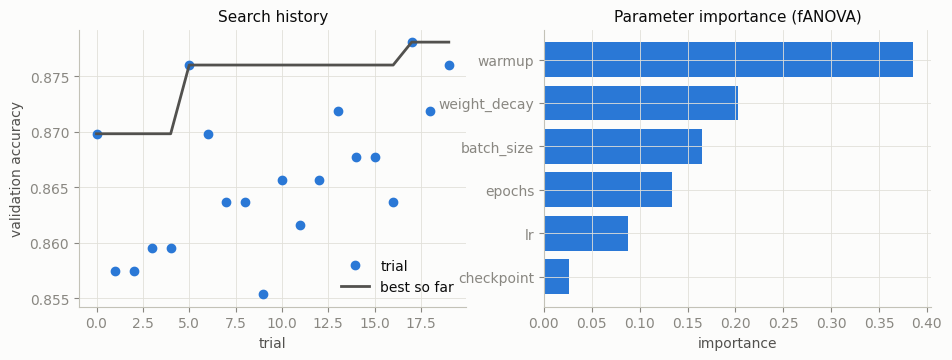

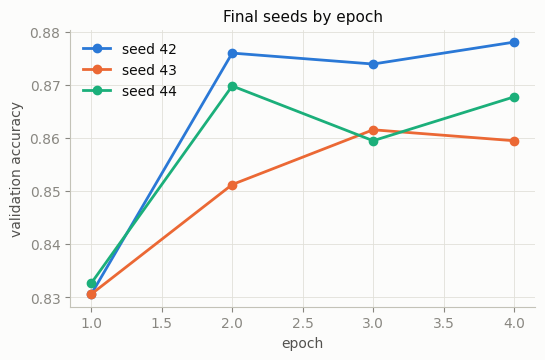

In [8]:
values = [t.value for t in study.trials]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(range(len(values)), values, "o", color=SERIES[0], label="trial")
axes[0].plot(range(len(values)), np.maximum.accumulate(values), color=INK_2, label="best so far")
axes[0].set_xlabel("trial")
axes[0].set_ylabel("validation accuracy")
axes[0].set_title("Search history")
axes[0].legend()
if not SMOKE:
    importances = optuna.importance.get_param_importances(study, evaluator=optuna.importance.FanovaImportanceEvaluator(seed=SEED))
    print("parameter importances: " + ", ".join(f"{k} {v:.3f}" for k, v in importances.items()))
    axes[1].barh(list(importances)[::-1], list(importances.values())[::-1], color=SERIES[0])
    axes[1].set_xlabel("importance")
axes[1].set_title("Parameter importance (fANOVA)")
save(fig, "search")
fig, ax = plt.subplots(figsize=(6, 3.6))
for i, (seed, curve) in enumerate(curves.items()):
    ax.plot(range(1, len(curve) + 1), curve, marker="o", color=SERIES[i], label=f"seed {seed}")
ax.set_xlabel("epoch")
ax.set_ylabel("validation accuracy")
ax.set_title("Final seeds by epoch")
ax.legend()
save(fig, "final_seeds")

**Conclusion.** The search history climbs in two steps, at trial 5 and trial 17, inside a 2.3-point band. fANOVA attributes most of the variation to warmup (0.385) and weight decay (0.202), with the checkpoint mattering least (0.026). The seed figure shows all three seeds leaving epoch 1 near 83% and settling between 86% and 88%.

## Outputs

Saves the headline model in safetensors format with its tokenizer (as a `tokenizers` JSON file that the serving app loads without PyTorch), every seed's probabilities, the reference probabilities, the chosen settings and the trial table.

In [9]:
model_dir = OUT / "model"
chosen_model.save_pretrained(model_dir)
tokenizers_by_name[best["checkpoint"]].save(str(model_dir / "tokenizer.json"))
shutil.copy(paths[best["checkpoint"]] / "vocab.txt", model_dir / "vocab.txt")
rows = []
for final in finals:
    for split in ("val", "test"):
        probs = final[split]
        rows.append(pd.DataFrame({"sentence_id": splits[split]["sentence_id"].to_numpy(), "split": split, "seed": final["seed"], "p_neg": probs[:, 0], "p_neu": probs[:, 1], "p_pos": probs[:, 2]}))
pd.concat(rows, ignore_index=True).to_parquet(OUT / "finetune_pred.parquet", index=False)
prosus_rows = [pd.DataFrame({"sentence_id": splits[split]["sentence_id"].to_numpy(), "split": split, "p_neg": p[:, 0], "p_neu": p[:, 1], "p_pos": p[:, 2]}) for split, p in prosus_probs.items()]
pd.concat(prosus_rows, ignore_index=True).to_parquet(OUT / "prosus_pred.parquet", index=False)
record = {**best, "seed": chosen, "val_accuracy": {str(f["seed"]): f["val_accuracy"] for f in finals}, "search_best_val_accuracy": study.best_value, "trials": TRIALS, "revisions": {name: rev for name, (_, rev) in CHECKPOINTS.items()}}
(OUT / "best_params.json").write_text(json.dumps(record, indent=2), encoding="utf-8")
study.trials_dataframe(attrs=("number", "value", "params", "state")).to_csv(OUT / "optuna_trials.csv", index=False)
for path in sorted(model_dir.iterdir()):
    print(f"model/{path.name}: {path.stat().st_size / 1e6:.1f} MB")
print(elapsed())

model/config.json: 0.0 MB
model/model.safetensors: 439.0 MB
model/tokenizer.json: 0.7 MB
model/vocab.txt: 0.2 MB
elapsed 65.8 minutes


**Conclusion.** The headline model is saved in safetensors format (439 MB) with its tokenizer file and vocabulary, next to every seed's validation and test probabilities, the ProsusAI reference probabilities, the chosen settings and the trial table. The whole run took 70.4 minutes of T4 time.